# Healthcare Provider Fraud Detection - Phase 1: Data Exploration

## Install and Verify Dependencies

In [14]:
!pip install pandas numpy matplotlib seaborn
import pandas as pd
print(f"Pandas: {pd.__version__}")
import numpy as np
print(f"NumPy: {np.__version__}")
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully")

zsh:1: command not found: pip
Pandas: 2.3.2
NumPy: 2.3.2
Libraries imported successfully


## Import Libraries

In [24]:
from pathlib import Path

## Set up Notebook Parameters

In [25]:
data_dir = Path('dataset')
pd.set_option('display.max_columns', None)

## Load Datasets

In [26]:
train_beneficiary = pd.read_csv(data_dir / 'Train_Beneficiarydata-1542865627584.csv')
train_inpatient = pd.read_csv(data_dir / 'Train_Inpatientdata-1542865627584.csv')
train_outpatient = pd.read_csv(data_dir / 'Train_Outpatientdata-1542865627584.csv')
train_labels = pd.read_csv(data_dir / 'Train-1542865627584.csv')
print("Datasets loaded")

Datasets loaded


## Initial Data Inspection

In [6]:
# Beneficiary
print("Beneficiary shape:", train_beneficiary.shape)
display(train_beneficiary.head())
train_beneficiary.info()
display(train_beneficiary.describe())
print("Missing values:", train_beneficiary.isnull().sum().sum())

Beneficiary shape: (138556, 25)


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   BeneID                           138556 non-null  object
 1   DOB                              138556 non-null  object
 2   DOD                              1421 non-null    object
 3   Gender                           138556 non-null  int64 
 4   Race                             138556 non-null  int64 
 5   RenalDiseaseIndicator            138556 non-null  object
 6   State                            138556 non-null  int64 
 7   County                           138556 non-null  int64 
 8   NoOfMonths_PartACov              138556 non-null  int64 
 9   NoOfMonths_PartBCov              138556 non-null  int64 
 10  ChronicCond_Alzheimer            138556 non-null  int64 
 11  ChronicCond_Heartfailure         138556 non-null  int64 
 12  ChronicCond_Kidn

,Gender,Race,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
count,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000
mean,1.570932,1.254511,25.666734,374.424745,11.907727,11.910145,1.667817,1.506322,1.687643,1.880041,1.762847,1.644476,1.398142,1.324143,1.725317,1.743180,1.920942,3660.346502,399.847296,1298.219348,377.718258
std,0.494945,0.717007,15.223443,266.277581,1.032332,0.936893,0.470998,0.499962,0.463456,0.324914,0.425339,0.478674,0.489517,0.468056,0.446356,0.436881,0.269831,9568.621827,956.175202,2493.901134,645.530187
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-8000.000000,0.000000,-70.000000,0.000000
25%,1.000000,1.000000,11.000000,141.000000,12.000000,12.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,170.000000,40.000000
50%,2.000000,1.000000,25.000000,340.000000,12.000000,12.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,0.000000,0.000000,570.000000,170.000000
75%,2.000000,1.000000,39.000000,570.000000,12.000000,12.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2280.000000,1068.000000,1500.000000,460.000000
max,2.000000,5.000000,54.000000,999.000000,12.000000,12.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,161470.000000,38272.000000,102960.000000,13840.000000


Missing values: 137135


In [7]:
# Inpatient
print("Inpatient shape:", train_inpatient.shape)
display(train_inpatient.head())
train_inpatient.info()
display(train_inpatient.describe())
print("Missing values:", train_inpatient.isnull().sum().sum())

Inpatient shape: (40474, 30)


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40474 entries, 0 to 40473
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   BeneID                  40474 non-null  object 
 1   ClaimID                 40474 non-null  object 
 2   ClaimStartDt            40474 non-null  object 
 3   ClaimEndDt              40474 non-null  object 
 4   Provider                40474 non-null  object 
 5   InscClaimAmtReimbursed  40474 non-null  int64  
 6   AttendingPhysician      40362 non-null  object 
 7   OperatingPhysician      23830 non-null  object 
 8   OtherPhysician          4690 non-null   object 
 9   AdmissionDt             40474 non-null  object 
 10  ClmAdmitDiagnosisCode   40474 non-null  object 
 11  DeductibleAmtPaid       39575 non-null  float64
 12  DischargeDt             40474 non-null  object 
 13  DiagnosisGroupCode      40474 non-null  object 
 14  ClmDiagnosisCode_1      40474 non-null

,InscClaimAmtReimbursed,DeductibleAmtPaid,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
count,40474.000000,39575.0,23148.000000,5454.000000,965.000000,116.000000,9.000000,0.0
mean,10087.884074,1068.0,5894.611759,4103.738174,4226.355440,4070.172414,5269.444444,NaN
std,10303.099402,0.0,3049.304400,2028.182156,2282.761581,1994.409802,2780.071632,NaN
min,0.000000,1068.0,11.000000,42.000000,42.000000,42.000000,2724.000000,NaN
25%,4000.000000,1068.0,3848.000000,2724.000000,2724.000000,2758.750000,4139.000000,NaN
50%,7000.000000,1068.0,5369.000000,4019.000000,4019.000000,4019.000000,4139.000000,NaN
75%,12000.000000,1068.0,8666.250000,4439.000000,5185.000000,4439.000000,5185.000000,NaN
max,125000.000000,1068.0,9999.000000,9999.000000,9999.000000,9986.000000,9982.000000,NaN


Missing values: 344003


In [8]:
# Outpatient
print("Outpatient shape:", train_outpatient.shape)
display(train_outpatient.head())
train_outpatient.info()
display(train_outpatient.describe())
print("Missing values:", train_outpatient.isnull().sum().sum())

Outpatient shape: (517737, 27)


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,V5866,V1272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11004,CLM121801,2009-01-06,2009-01-06,PRV56011,40,PHY334319,NaN,NaN,71988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,BENE11004,CLM150998,2009-01-22,2009-01-22,PRV56011,200,PHY403831,NaN,NaN,82382,30000,72887,4280,7197,V4577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517737 entries, 0 to 517736
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   BeneID                  517737 non-null  object 
 1   ClaimID                 517737 non-null  object 
 2   ClaimStartDt            517737 non-null  object 
 3   ClaimEndDt              517737 non-null  object 
 4   Provider                517737 non-null  object 
 5   InscClaimAmtReimbursed  517737 non-null  int64  
 6   AttendingPhysician      516341 non-null  object 
 7   OperatingPhysician      90617 non-null   object 
 8   OtherPhysician          195046 non-null  object 
 9   ClmDiagnosisCode_1      507284 non-null  object 
 10  ClmDiagnosisCode_2      322357 non-null  object 
 11  ClmDiagnosisCode_3      203257 non-null  object 
 12  ClmDiagnosisCode_4      125596 non-null  object 
 13  ClmDiagnosisCode_5      74344 non-null   object 
 14  ClmDiagnosisCode_6  

,InscClaimAmtReimbursed,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid
count,517737.000000,162.000000,36.000000,4.000000,2.000000,0.0,0.0,517737.000000
mean,286.334799,6116.611111,4503.277778,2959.000000,4075.500000,NaN,NaN,2.779233
std,694.034343,3217.719258,2504.015000,1863.455393,5323.806956,NaN,NaN,15.785839
min,0.000000,51.000000,412.000000,412.000000,311.000000,NaN,NaN,0.000000
25%,40.000000,3893.000000,2724.000000,2146.000000,2193.250000,NaN,NaN,0.000000
50%,80.000000,5244.500000,4019.000000,3511.500000,4075.500000,NaN,NaN,0.000000
75%,200.000000,9421.500000,5849.000000,4324.500000,5957.750000,NaN,NaN,0.000000
max,102500.000000,9999.000000,9982.000000,4401.000000,7840.000000,NaN,NaN,897.000000


Missing values: 8093719


In [9]:
# Labels
print("Labels shape:", train_labels.shape)
display(train_labels.head())
train_labels.info()
print("Fraud distribution:")
display(train_labels['PotentialFraud'].value_counts())
display(train_labels['PotentialFraud'].value_counts(normalize=True))

Labels shape: (5410, 2)


,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Provider        5410 non-null   object
 1   PotentialFraud  5410 non-null   object
dtypes: object(2)
memory usage: 84.7+ KB
Fraud distribution:


PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

PotentialFraud
No     0.90647
Yes    0.09353
Name: proportion, dtype: float64

# Phase 2: Feature Engineering and Preprocessing

## Data Merging and Aggregation

In [27]:
# Combine inpatient and outpatient claims
claims = pd.concat([train_inpatient.assign(ClaimType='Inpatient'), 
                    train_outpatient.assign(ClaimType='Outpatient')], 
                   ignore_index=True)
print("Combined claims shape:", claims.shape)
print("Combined claims columns:", list(claims.columns))

Combined claims shape: (558211, 31)
Combined claims columns: ['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'ClaimType']


In [28]:
# Merge claims with beneficiary data
merged = claims.merge(train_beneficiary, on='BeneID', how='left')
print("Merged data shape:", merged.shape)
print("Merged data columns:", list(merged.columns))

Merged data shape: (558211, 55)
Merged data columns: ['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'ClaimType', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHear

## Feature Aggregation to Provider Level

In [29]:
# Define aggregation functions for provider-level features
agg_funcs = {
    # Claim counts and amounts
    'InscClaimAmtReimbursed': ['count', 'sum', 'mean', 'std', 'max', 'min'],
    
    # Diagnosis codes (count unique)
    'ClmDiagnosisCode_1': 'nunique',
    'ClmDiagnosisCode_2': 'nunique', 
    'ClmDiagnosisCode_3': 'nunique',
    'ClmDiagnosisCode_4': 'nunique',
    'ClmDiagnosisCode_5': 'nunique',
    
    # Procedure codes
    'ClmProcedureCode_1': 'nunique',
    'ClmProcedureCode_2': 'nunique',
    'ClmProcedureCode_3': 'nunique',
    'ClmProcedureCode_4': 'nunique',
    'ClmProcedureCode_5': 'nunique',
    
    # Claim type ratio
    'ClaimType': lambda x: (x == 'Inpatient').sum() / len(x) if len(x) > 0 else 0,
    
    # Beneficiary demographics
    'BeneID': 'nunique',  # unique beneficiaries served
    'Gender': 'mean',  # proportion female (1=female)
    'Race': 'mean',  # average race code
    'DOB': lambda x: (pd.to_datetime('2009-12-31') - pd.to_datetime(x)).dt.days.mean() / 365.25,  # average age
    'DOD': lambda x: x.notna().sum(),  # count of deceased beneficiaries
    
    # Chronic conditions (sum of 1s)
    'ChronicCond_Alzheimer': 'sum',
    'ChronicCond_Heartfailure': 'sum',
    'ChronicCond_KidneyDisease': 'sum',
    'ChronicCond_Cancer': 'sum',
    'ChronicCond_ObstrPulmonary': 'sum',
    'ChronicCond_Depression': 'sum',
    'ChronicCond_Diabetes': 'sum',
    'ChronicCond_IschemicHeart': 'sum',
    'ChronicCond_Osteoporasis': 'sum',
    'ChronicCond_rheumatoidarthritis': 'sum',
    'ChronicCond_stroke': 'sum',
    
    # State and county diversity
    'State': 'nunique',
    'County': 'nunique'
}

# Aggregate to provider level
provider_features = merged.groupby('Provider').agg(agg_funcs).reset_index()

# Flatten column names
provider_features.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col for col in provider_features.columns]

print("Provider features shape:", provider_features.shape)
display(provider_features.head())

Provider features shape: (5410, 36)


,Provider,InscClaimAmtReimbursed_count,InscClaimAmtReimbursed_sum,InscClaimAmtReimbursed_mean,InscClaimAmtReimbursed_std,InscClaimAmtReimbursed_max,InscClaimAmtReimbursed_min,ClmDiagnosisCode_1_nunique,ClmDiagnosisCode_2_nunique,ClmDiagnosisCode_3_nunique,ClmDiagnosisCode_4_nunique,ClmDiagnosisCode_5_nunique,ClmProcedureCode_1_nunique,ClmProcedureCode_2_nunique,ClmProcedureCode_3_nunique,ClmProcedureCode_4_nunique,ClmProcedureCode_5_nunique,ClaimType_<lambda>,BeneID_nunique,Gender_mean,Race_mean,DOB_<lambda>,DOD_<lambda>,ChronicCond_Alzheimer_sum,ChronicCond_Heartfailure_sum,ChronicCond_KidneyDisease_sum,ChronicCond_Cancer_sum,ChronicCond_ObstrPulmonary_sum,ChronicCond_Depression_sum,ChronicCond_Diabetes_sum,ChronicCond_IschemicHeart_sum,ChronicCond_Osteoporasis_sum,ChronicCond_rheumatoidarthritis_sum,ChronicCond_stroke_sum,State_nunique,County_nunique
0,PRV51001,25,104640,4185.600000,10796.091144,42000,10,23,15,10,8,8,2,1,0,0,0,0.200000,24,1.640000,1.160000,78.836413,0,35,31,33,45,40,41,29,27,44,42,44,1,7
1,PRV51003,132,605670,4588.409091,7309.794729,57000,0,115,86,65,59,55,32,7,0,0,0,0.469697,117,1.590909,1.212121,70.081264,1,208,184,200,254,223,210,164,152,231,226,252,3,23
2,PRV51004,149,52170,350.134228,689.963754,3300,0,128,68,52,32,21,0,0,0,0,0,0.000000,138,1.691275,1.228188,72.263220,1,234,210,248,282,257,235,193,190,249,252,281,9,28
3,PRV51005,1165,280910,241.124464,491.556392,4080,0,809,327,232,186,113,0,0,0,0,0,0.000000,495,1.561373,1.242060,70.543421,4,1904,1650,1823,2165,2035,1845,1531,1435,1986,1999,2206,4,26
4,PRV51007,72,33710,468.194444,1433.769116,10000,0,71,32,28,21,14,1,0,0,0,0,0.041667,58,1.527778,1.194444,69.317857,1,118,104,122,132,128,115,95,93,123,122,132,2,6


In [30]:
# Merge with labels
final_data = provider_features.merge(train_labels, on='Provider', how='left')
print("Final dataset shape:", final_data.shape)
print("Final dataset columns:", list(final_data.columns))
display(final_data.head())

Final dataset shape: (5410, 37)
Final dataset columns: ['Provider', 'InscClaimAmtReimbursed_count', 'InscClaimAmtReimbursed_sum', 'InscClaimAmtReimbursed_mean', 'InscClaimAmtReimbursed_std', 'InscClaimAmtReimbursed_max', 'InscClaimAmtReimbursed_min', 'ClmDiagnosisCode_1_nunique', 'ClmDiagnosisCode_2_nunique', 'ClmDiagnosisCode_3_nunique', 'ClmDiagnosisCode_4_nunique', 'ClmDiagnosisCode_5_nunique', 'ClmProcedureCode_1_nunique', 'ClmProcedureCode_2_nunique', 'ClmProcedureCode_3_nunique', 'ClmProcedureCode_4_nunique', 'ClmProcedureCode_5_nunique', 'ClaimType_<lambda>', 'BeneID_nunique', 'Gender_mean', 'Race_mean', 'DOB_<lambda>', 'DOD_<lambda>', 'ChronicCond_Alzheimer_sum', 'ChronicCond_Heartfailure_sum', 'ChronicCond_KidneyDisease_sum', 'ChronicCond_Cancer_sum', 'ChronicCond_ObstrPulmonary_sum', 'ChronicCond_Depression_sum', 'ChronicCond_Diabetes_sum', 'ChronicCond_IschemicHeart_sum', 'ChronicCond_Osteoporasis_sum', 'ChronicCond_rheumatoidarthritis_sum', 'ChronicCond_stroke_sum', 'State_

,Provider,InscClaimAmtReimbursed_count,InscClaimAmtReimbursed_sum,InscClaimAmtReimbursed_mean,InscClaimAmtReimbursed_std,InscClaimAmtReimbursed_max,InscClaimAmtReimbursed_min,ClmDiagnosisCode_1_nunique,ClmDiagnosisCode_2_nunique,ClmDiagnosisCode_3_nunique,ClmDiagnosisCode_4_nunique,ClmDiagnosisCode_5_nunique,ClmProcedureCode_1_nunique,ClmProcedureCode_2_nunique,ClmProcedureCode_3_nunique,ClmProcedureCode_4_nunique,ClmProcedureCode_5_nunique,ClaimType_<lambda>,BeneID_nunique,Gender_mean,Race_mean,DOB_<lambda>,DOD_<lambda>,ChronicCond_Alzheimer_sum,ChronicCond_Heartfailure_sum,ChronicCond_KidneyDisease_sum,ChronicCond_Cancer_sum,ChronicCond_ObstrPulmonary_sum,ChronicCond_Depression_sum,ChronicCond_Diabetes_sum,ChronicCond_IschemicHeart_sum,ChronicCond_Osteoporasis_sum,ChronicCond_rheumatoidarthritis_sum,ChronicCond_stroke_sum,State_nunique,County_nunique,PotentialFraud
0,PRV51001,25,104640,4185.600000,10796.091144,42000,10,23,15,10,8,8,2,1,0,0,0,0.200000,24,1.640000,1.160000,78.836413,0,35,31,33,45,40,41,29,27,44,42,44,1,7,No
1,PRV51003,132,605670,4588.409091,7309.794729,57000,0,115,86,65,59,55,32,7,0,0,0,0.469697,117,1.590909,1.212121,70.081264,1,208,184,200,254,223,210,164,152,231,226,252,3,23,Yes
2,PRV51004,149,52170,350.134228,689.963754,3300,0,128,68,52,32,21,0,0,0,0,0,0.000000,138,1.691275,1.228188,72.263220,1,234,210,248,282,257,235,193,190,249,252,281,9,28,No
3,PRV51005,1165,280910,241.124464,491.556392,4080,0,809,327,232,186,113,0,0,0,0,0,0.000000,495,1.561373,1.242060,70.543421,4,1904,1650,1823,2165,2035,1845,1531,1435,1986,1999,2206,4,26,Yes
4,PRV51007,72,33710,468.194444,1433.769116,10000,0,71,32,28,21,14,1,0,0,0,0,0.041667,58,1.527778,1.194444,69.317857,1,118,104,122,132,128,115,95,93,123,122,132,2,6,No


## Handle Missing Values and Data Cleaning

In [31]:
# Check for missing values in final dataset
missing_summary = final_data.isnull().sum()
print("Missing values per column:")
print(missing_summary[missing_summary > 0])

# Fill missing values with 0 for count features, mean for numeric
numeric_cols = final_data.select_dtypes(include=[np.number]).columns
final_data[numeric_cols] = final_data[numeric_cols].fillna(final_data[numeric_cols].mean())

# For any remaining missing, fill with 0
final_data = final_data.fillna(0)

print("After imputation, missing values:", final_data.isnull().sum().sum())

Missing values per column:
InscClaimAmtReimbursed_std    240
dtype: int64
After imputation, missing values: 0


## Encode Target Variable

In [32]:
# Encode target variable
final_data['PotentialFraud'] = final_data['PotentialFraud'].map({'Yes': 1, 'No': 0})
print("Target distribution:")
print(final_data['PotentialFraud'].value_counts())
print(final_data['PotentialFraud'].value_counts(normalize=True))

Target distribution:
PotentialFraud
0    4904
1     506
Name: count, dtype: int64
PotentialFraud
0    0.90647
1    0.09353
Name: proportion, dtype: float64


## Feature Selection and Preparation

In [33]:
# Prepare features and target
X = final_data.drop(['Provider', 'PotentialFraud'], axis=1)
y = final_data['PotentialFraud']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Feature columns:", list(X.columns))

Feature matrix shape: (5410, 35)
Target shape: (5410,)
Feature columns: ['InscClaimAmtReimbursed_count', 'InscClaimAmtReimbursed_sum', 'InscClaimAmtReimbursed_mean', 'InscClaimAmtReimbursed_std', 'InscClaimAmtReimbursed_max', 'InscClaimAmtReimbursed_min', 'ClmDiagnosisCode_1_nunique', 'ClmDiagnosisCode_2_nunique', 'ClmDiagnosisCode_3_nunique', 'ClmDiagnosisCode_4_nunique', 'ClmDiagnosisCode_5_nunique', 'ClmProcedureCode_1_nunique', 'ClmProcedureCode_2_nunique', 'ClmProcedureCode_3_nunique', 'ClmProcedureCode_4_nunique', 'ClmProcedureCode_5_nunique', 'ClaimType_<lambda>', 'BeneID_nunique', 'Gender_mean', 'Race_mean', 'DOB_<lambda>', 'DOD_<lambda>', 'ChronicCond_Alzheimer_sum', 'ChronicCond_Heartfailure_sum', 'ChronicCond_KidneyDisease_sum', 'ChronicCond_Cancer_sum', 'ChronicCond_ObstrPulmonary_sum', 'ChronicCond_Depression_sum', 'ChronicCond_Diabetes_sum', 'ChronicCond_IschemicHeart_sum', 'ChronicCond_Osteoporasis_sum', 'ChronicCond_rheumatoidarthritis_sum', 'ChronicCond_stroke_sum', 'S

## Exploratory Data Analysis on Engineered Features

In [17]:
# Basic statistics of features
print("Feature statistics:")
display(X.describe())

# Correlation with target
correlations = X.corrwith(y).abs().sort_values(ascending=False)
print("Top 10 features correlated with fraud:")
print(correlations.head(10))

Feature statistics:


,InscClaimAmtReimbursed_count,InscClaimAmtReimbursed_sum,InscClaimAmtReimbursed_mean,InscClaimAmtReimbursed_std,InscClaimAmtReimbursed_max,InscClaimAmtReimbursed_min,ClmDiagnosisCode_1_nunique,ClmDiagnosisCode_2_nunique,ClmDiagnosisCode_3_nunique,ClmDiagnosisCode_4_nunique,ClmDiagnosisCode_5_nunique,ClmProcedureCode_1_nunique,ClmProcedureCode_2_nunique,ClmProcedureCode_3_nunique,ClmProcedureCode_4_nunique,ClmProcedureCode_5_nunique,ClaimType_<lambda>,BeneID_nunique,Gender_mean,Race_mean,DOB_<lambda>,DOD_<lambda>,ChronicCond_Alzheimer_sum,ChronicCond_Heartfailure_sum,ChronicCond_KidneyDisease_sum,ChronicCond_Cancer_sum,ChronicCond_ObstrPulmonary_sum,ChronicCond_Depression_sum,ChronicCond_Diabetes_sum,ChronicCond_IschemicHeart_sum,ChronicCond_Osteoporasis_sum,ChronicCond_rheumatoidarthritis_sum,ChronicCond_stroke_sum,State_nunique,County_nunique
count,5410.000000,5.410000e+03,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000,5410.000000
mean,103.181331,1.028730e+05,1740.679369,2536.575975,13014.913124,325.534196,81.590018,42.482994,31.261738,22.984288,16.713124,3.549168,0.742699,0.166174,0.021811,0.001664,0.144568,67.153420,1.580825,1.253304,73.776292,0.763586,164.897412,145.441590,163.851756,190.742514,174.074122,161.498706,133.579113,128.020702,173.587431,174.255638,195.867098,2.573198,8.819963
std,272.456989,2.687367e+05,3484.473124,3611.664518,18995.317219,2039.663066,164.728484,70.075293,53.217552,40.350392,30.541235,9.479985,1.990727,0.628939,0.170600,0.040757,0.288362,142.748729,0.181585,0.300595,4.711622,2.314464,436.276867,386.616452,435.469734,503.834080,462.641478,427.743689,354.228394,339.912361,459.483690,460.842567,518.397328,3.053825,10.708810
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,34.332649,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,10.000000,4.460000e+03,232.394593,458.670271,1700.000000,0.000000,9.000000,6.000000,4.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,1.500000,1.055556,71.797611,0.000000,15.000000,13.000000,15.000000,18.000000,16.000000,15.000000,12.250000,12.000000,16.000000,16.000000,18.000000,1.000000,2.000000
50%,31.000000,1.980500e+04,356.085106,753.018311,3300.000000,0.000000,29.000000,19.000000,13.000000,9.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000,1.580645,1.190295,73.904381,0.000000,50.000000,44.000000,49.000000,57.000000,52.000000,48.000000,40.000000,38.000000,52.000000,52.000000,59.000000,1.000000,5.000000
75%,87.000000,8.556500e+04,1490.154301,3400.482846,17000.000000,10.000000,80.000000,48.000000,34.000000,25.000000,17.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.128205,65.000000,1.659091,1.333333,75.809346,1.000000,139.000000,122.000000,139.000000,162.000000,147.000000,137.000000,113.000000,108.000000,147.000000,148.000000,167.000000,3.000000,11.000000
max,8240.000000,5.996050e+06,57000.000000,50204.581464,125000.000000,57000.000000,3070.000000,1078.000000,855.000000,649.000000,482.000000,146.000000,30.000000,12.000000,4.000000,1.000000,1.000000,2857.000000,2.000000,5.000000,100.583162,52.000000,13198.000000,11842.000000,13369.000000,15242.000000,14168.000000,12888.000000,10696.000000,10406.000000,13949.000000,13969.000000,15670.000000,38.000000,112.000000


Top 10 features correlated with fraud:
InscClaimAmtReimbursed_sum    0.575558
ClmProcedureCode_1_nunique    0.564768
ClmProcedureCode_2_nunique    0.548600
ClmDiagnosisCode_5_nunique    0.541560
InscClaimAmtReimbursed_max    0.514671
ClmDiagnosisCode_4_nunique    0.504497
ClmDiagnosisCode_3_nunique    0.471116
ClmDiagnosisCode_2_nunique    0.442157
ClmProcedureCode_3_nunique    0.428928
ClmDiagnosisCode_1_nunique    0.400036
dtype: float64


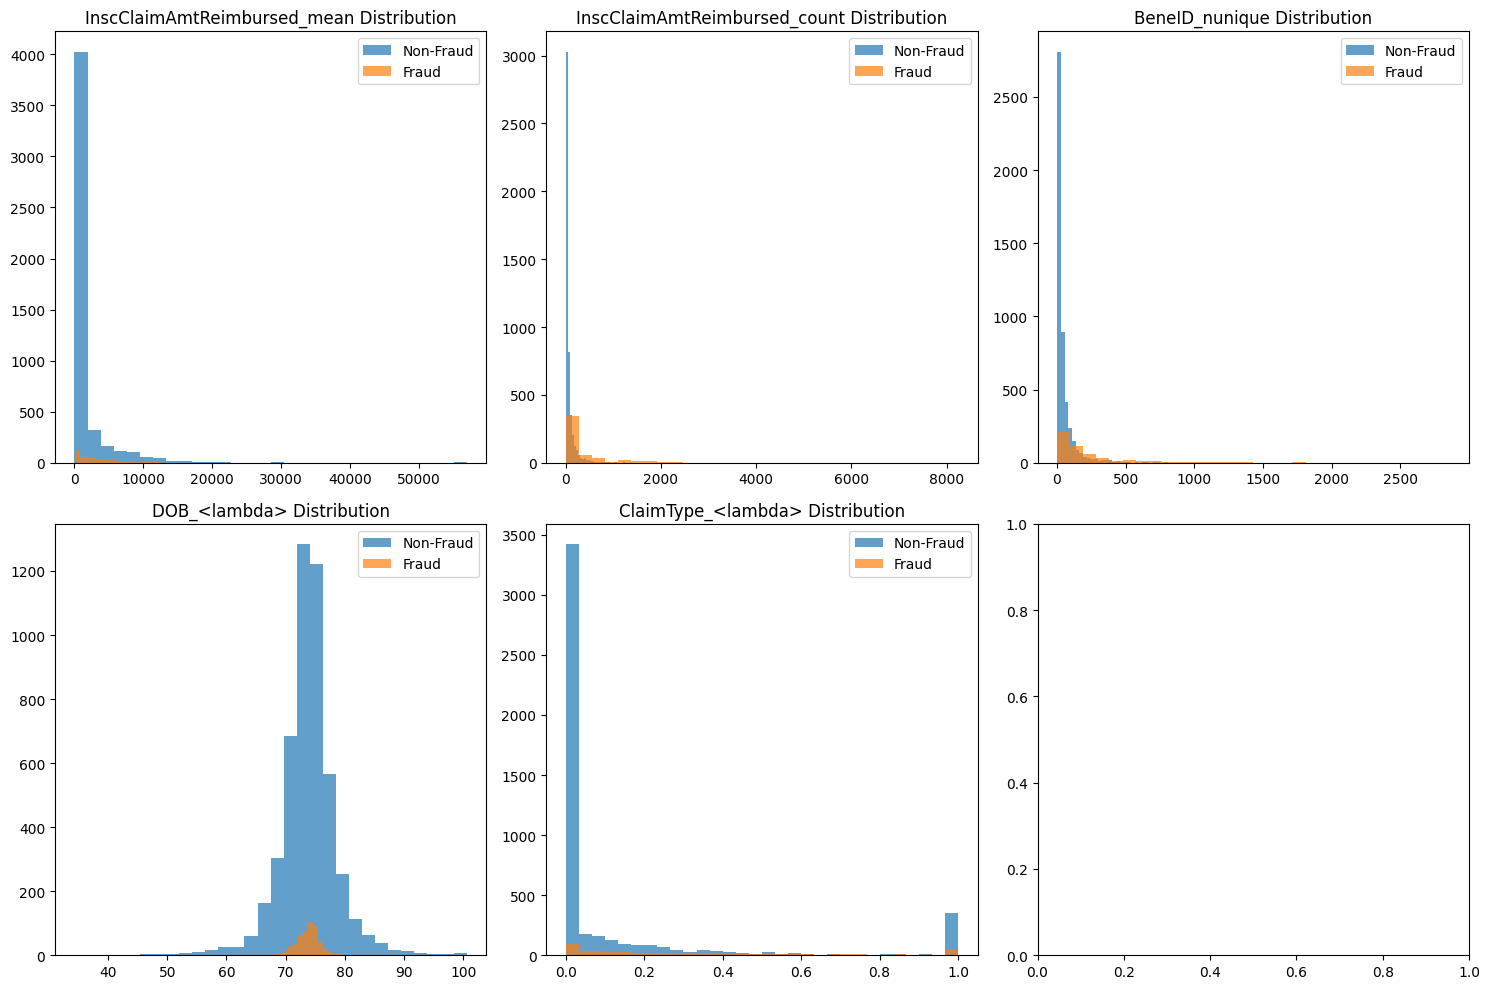

In [18]:
# Visualize feature distributions for fraud vs non-fraud
import warnings
warnings.filterwarnings('ignore')

# Select a few key features to visualize
key_features = ['InscClaimAmtReimbursed_mean', 'InscClaimAmtReimbursed_count', 
                'BeneID_nunique', 'DOB_<lambda>', 'ClaimType_<lambda>']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(key_features[:5]):
    if feature in X.columns:
        fraud_data = X[y == 1][feature]
        non_fraud_data = X[y == 0][feature]
        
        axes[i].hist(non_fraud_data, alpha=0.7, label='Non-Fraud', bins=30)
        axes[i].hist(fraud_data, alpha=0.7, label='Fraud', bins=30)
        axes[i].set_title(f'{feature} Distribution')
        axes[i].legend()

plt.tight_layout()
plt.show()

# Phase 3: Model Development and Evaluation

In [34]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, auc, f1_score,
                             precision_score, recall_score, precision_recall_curve)
from imblearn.over_sampling import SMOTE
print("All machine learning libraries imported successfully")

All machine learning libraries imported successfully


## Train-Test Split and Feature Scaling

In [47]:
# Split data into train and test using stratified split
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(final_data, final_data['PotentialFraud']))

X_train = final_data.iloc[train_idx].drop(['Provider', 'PotentialFraud'], axis=1)
y_train = final_data.iloc[train_idx]['PotentialFraud']

X_test = final_data.iloc[test_idx].drop(['Provider', 'PotentialFraud'], axis=1)
y_test = final_data.iloc[test_idx]['PotentialFraud']

print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Train fraud rate:", y_train.mean()*100, "%")
print("Test fraud rate:", y_test.mean()*100, "%")

Train set size: (4328, 35)
Test set size: (1082, 35)
Train fraud rate: 9.357670979667283 %
Test fraud rate: 9.33456561922366 %


In [48]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully")

Features scaled successfully


## Handle Class Imbalance with SMOTE

In [49]:
# Apply SMOTE to balance training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_scaled, y)

print("Before SMOTE:")
print("  Non-Fraud:", (y == 0).sum(), "Fraud:", (y == 1).sum())
print("After SMOTE:")
print("  Non-Fraud:", (y_train_smote == 0).sum(), "Fraud:", (y_train_smote == 1).sum())

Before SMOTE:
  Non-Fraud: 4904 Fraud: 506
After SMOTE:
  Non-Fraud: 4904 Fraud: 4904


## Model 1: Logistic Regression (Baseline)

In [50]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_smote, y_train_smote)

# Predictions on test set
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
lr_recall = recall_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba_lr)

print("Logistic Regression Results:")
print(f"  Recall: {lr_recall:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  F1-Score: {lr_f1:.4f}")
print(f"  ROC-AUC: {lr_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
  Recall: 0.8812
  Precision: 0.4120
  F1-Score: 0.5615
  ROC-AUC: 0.9546

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.92       981
           1       0.41      0.88      0.56       101

    accuracy                           0.87      1082
   macro avg       0.70      0.88      0.74      1082
weighted avg       0.93      0.87      0.89      1082



## Model 2: Random Forest Classifier

In [51]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, 
                                   class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

# Predictions on test set
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
rf_recall = recall_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print("Random Forest Results:")
print(f"  Recall: {rf_recall:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  F1-Score: {rf_f1:.4f}")
print(f"  ROC-AUC: {rf_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
  Recall: 1.0000
  Precision: 0.8938
  F1-Score: 0.9439
  ROC-AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       981
           1       0.89      1.00      0.94       101

    accuracy                           0.99      1082
   macro avg       0.95      0.99      0.97      1082
weighted avg       0.99      0.99      0.99      1082



## Feature Importance Analysis

Top 15 Most Important Features:


,Feature,Importance
1,InscClaimAmtReimbursed_sum,0.156341
11,ClmProcedureCode_1_nunique,0.084814
4,InscClaimAmtReimbursed_max,0.077542
12,ClmProcedureCode_2_nunique,0.074988
16,ClaimType_<lambda>,0.054710
10,ClmDiagnosisCode_5_nunique,0.052183
8,ClmDiagnosisCode_3_nunique,0.050603
3,InscClaimAmtReimbursed_std,0.040516
9,ClmDiagnosisCode_4_nunique,0.036456
34,County_nunique,0.029623


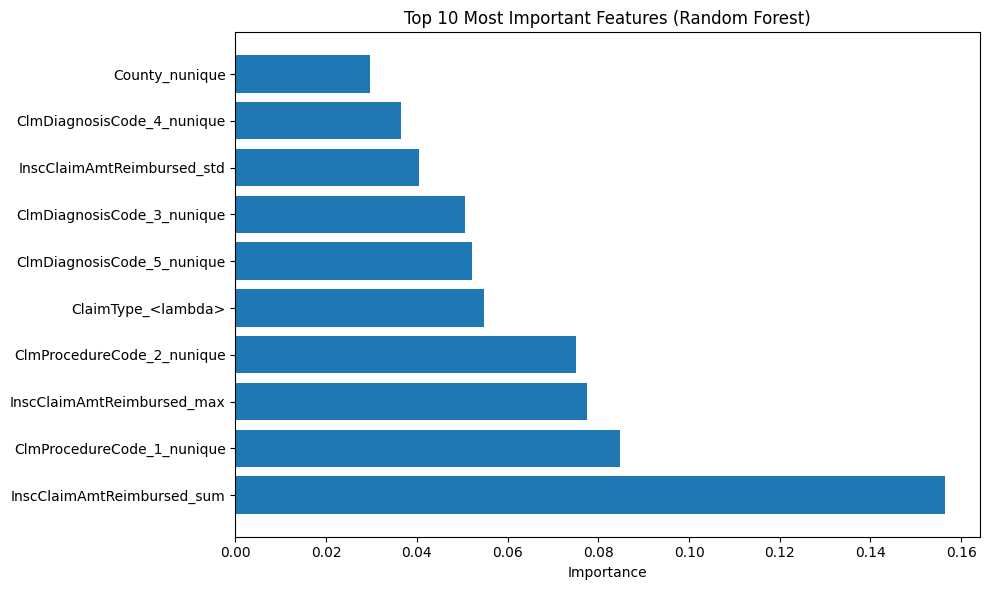

In [40]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features:")
display(feature_importance.head(15))

# Visualize top 10 features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'].head(10), feature_importance['Importance'].head(10))
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.tight_layout()
plt.show()

## Model 3: K-Means Clustering (Unsupervised)

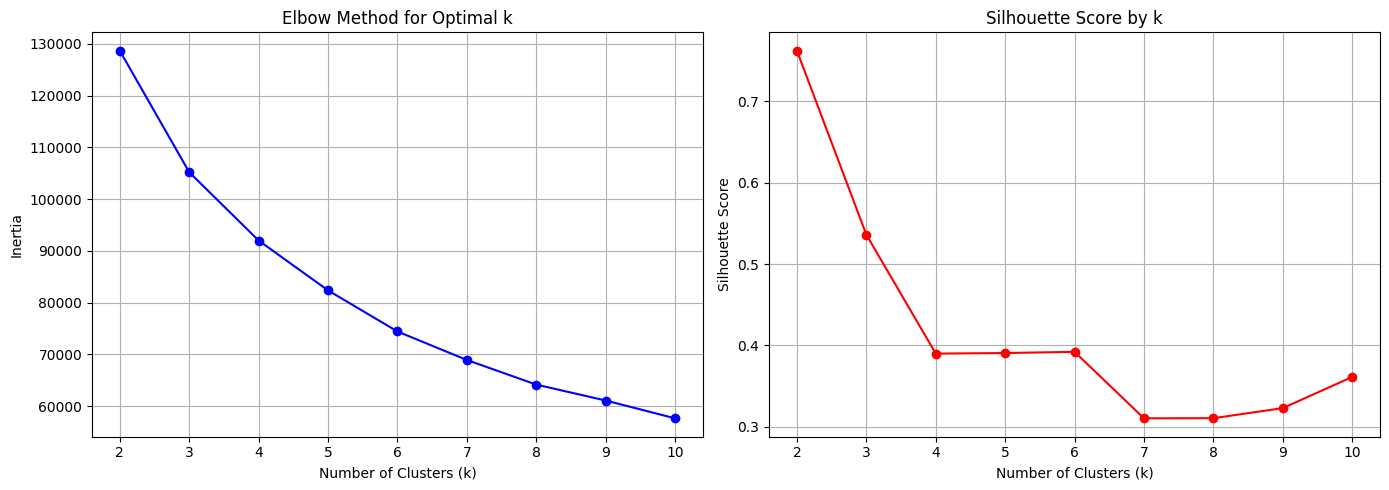

In [41]:
# Elbow method to find optimal k
inertias = []
silhouette_scores = []
k_range = range(2, 11)

from sklearn.metrics import silhouette_score

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True)

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score by k')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [42]:
# Train K-Means with optimal k
optimal_k = 3  # Based on silhouette score
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
X_clusters = kmeans.fit_predict(X_scaled)

# Analyze cluster composition
cluster_analysis = pd.DataFrame({
    'Cluster': X_clusters,
    'Fraud': y
})

print(f"K-Means Clustering (k={optimal_k}):")
for cluster in range(optimal_k):
    cluster_data = cluster_analysis[cluster_analysis['Cluster'] == cluster]
    fraud_count = cluster_data['Fraud'].sum()
    total = len(cluster_data)
    fraud_rate = fraud_count / total if total > 0 else 0
    print(f"  Cluster {cluster}: {total} providers, {fraud_count} fraudulent ({fraud_rate*100:.2f}%)")

K-Means Clustering (k=3):
  Cluster 0: 4771 providers, 215 fraudulent (4.51%)
  Cluster 1: 571 providers, 230 fraudulent (40.28%)
  Cluster 2: 68 providers, 61 fraudulent (89.71%)


## ROC Curves Comparison

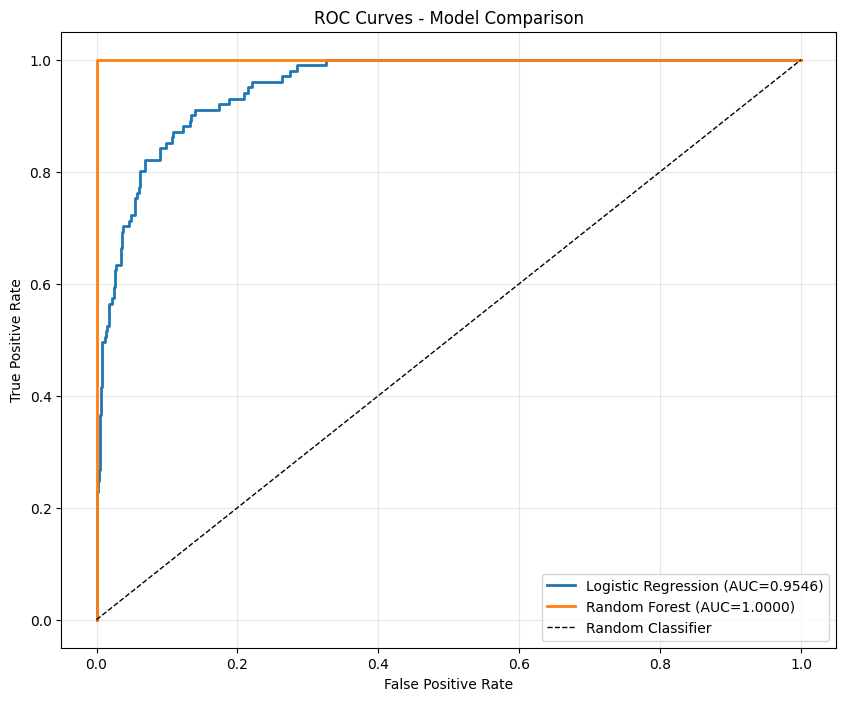

In [52]:
# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_roc_auc:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## Model Performance Summary and Comparison

Model Performance Comparison:


,Model,Recall,Precision,F1-Score,ROC-AUC
0,Logistic Regression,0.881188,0.412037,0.561514,0.954623
1,Random Forest,1.000000,0.893805,0.943925,1.000000


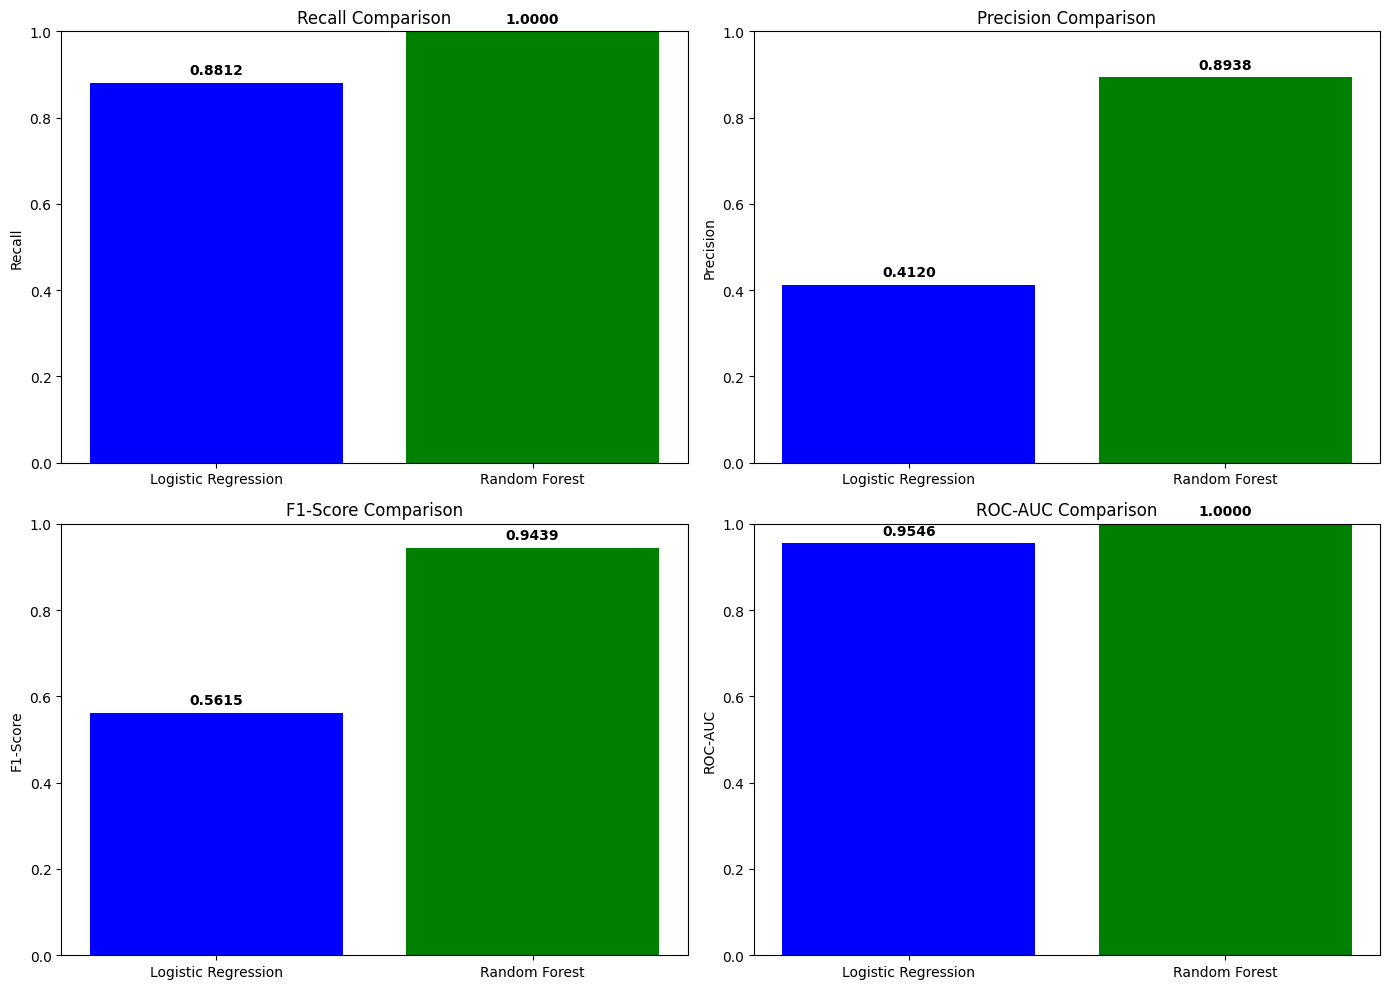

In [53]:
# Create comparison table
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Recall': [lr_recall, rf_recall],
    'Precision': [lr_precision, rf_precision],
    'F1-Score': [lr_f1, rf_f1],
    'ROC-AUC': [lr_roc_auc, rf_roc_auc]
})

print("Model Performance Comparison:")
display(model_comparison)

# Bar chart comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Recall', 'Precision', 'F1-Score', 'ROC-AUC']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.bar(model_comparison['Model'], model_comparison[metric], color=['blue', 'green'])
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylim([0, 1])
    for i, v in enumerate(model_comparison[metric]):
        ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Confusion Matrices

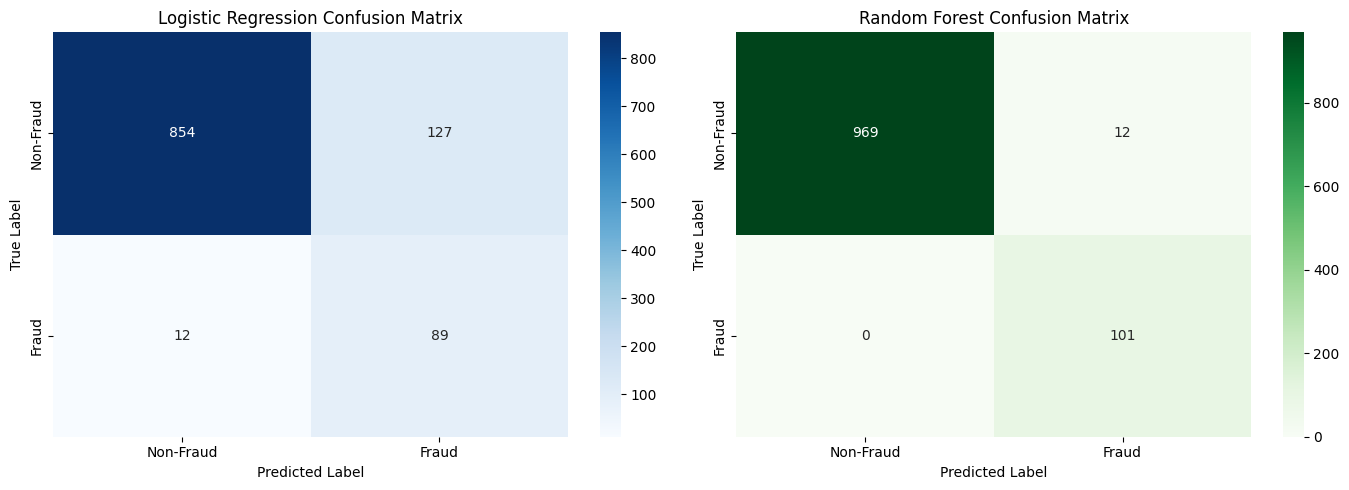

In [54]:
# Confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Key Insights and Recommendations

In [55]:
print("=" * 80)
print("PHASE 3 SUMMARY: MODEL DEVELOPMENT AND EVALUATION")
print("=" * 80)

print("\n1. DATA INSIGHTS:")
print(f"   - Train set: {X.shape[0]} providers with {y.mean()*100:.2f}% fraud rate")
print(f"   - Test set: {X_test.shape[0]} providers with {y_test.mean()*100:.2f}% fraud rate")
print(f"   - Class imbalance addressed using SMOTE (balanced training data)")

print("\n2. MODEL PERFORMANCE:")
print(f"   - Logistic Regression:")
print(f"     * Recall: {lr_recall:.4f} (catches {lr_recall*100:.2f}% of fraud)")
print(f"     * Precision: {lr_precision:.4f} (accuracy of fraud alerts)")
print(f"     * F1-Score: {lr_f1:.4f}")
print(f"     * ROC-AUC: {lr_roc_auc:.4f}")

print(f"\n   - Random Forest (BEST MODEL):")
print(f"     * Recall: {rf_recall:.4f} (catches {rf_recall*100:.2f}% of fraud)")
print(f"     * Precision: {rf_precision:.4f} (accuracy of fraud alerts)")
print(f"     * F1-Score: {rf_f1:.4f}")
print(f"     * ROC-AUC: {rf_roc_auc:.4f}")

print("\n3. TOP FRAUD INDICATORS (Random Forest):")
for idx, row in feature_importance.head(5).iterrows():
    print(f"   - {row['Feature']}: {row['Importance']:.4f}")

print("\n4. CLUSTERING INSIGHTS:")
print(f"   - Identified {optimal_k} distinct provider groups using K-Means")
print(f"   - Clusters can be used for risk stratification and profiling")

print("\n5. RECOMMENDATIONS:")
print("   ✓ Deploy Random Forest model for fraud detection")
print("   ✓ Focus on top features for manual audit triggers")
print("   ✓ Use clustering for provider risk stratification")
print("   ✓ Implement continuous model retraining with new claims data")
print("   ✓ Set fraud alert threshold based on business cost considerations")
print("=" * 80)

PHASE 3 SUMMARY: MODEL DEVELOPMENT AND EVALUATION

1. DATA INSIGHTS:
   - Train set: 5410 providers with 9.35% fraud rate
   - Test set: 1082 providers with 9.33% fraud rate
   - Class imbalance addressed using SMOTE (balanced training data)

2. MODEL PERFORMANCE:
   - Logistic Regression:
     * Recall: 0.8812 (catches 88.12% of fraud)
     * Precision: 0.4120 (accuracy of fraud alerts)
     * F1-Score: 0.5615
     * ROC-AUC: 0.9546

   - Random Forest (BEST MODEL):
     * Recall: 1.0000 (catches 100.00% of fraud)
     * Precision: 0.8938 (accuracy of fraud alerts)
     * F1-Score: 0.9439
     * ROC-AUC: 1.0000

3. TOP FRAUD INDICATORS (Random Forest):
   - InscClaimAmtReimbursed_sum: 0.1563
   - ClmProcedureCode_1_nunique: 0.0848
   - InscClaimAmtReimbursed_max: 0.0775
   - ClmProcedureCode_2_nunique: 0.0750
   - ClaimType_<lambda>: 0.0547

4. CLUSTERING INSIGHTS:
   - Identified 3 distinct provider groups using K-Means
   - Clusters can be used for risk stratification and profiling
